## Importando as bibliotecas 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, roc_auc_score, auc, precision_score, recall_score, f1_score, precision_recall_curve, confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance

import ace_tools_open as tools 

import xgboost as xgb
import lightgbm as lgb

import pickle

import optuna
from optuna.pruners import SuccessiveHalvingPruner
from optuna.exceptions import TrialPruned

sns.set_theme(style="whitegrid", palette="pastel")
pd.set_option('display.max_rows',99)
pd.set_option('display.max_columns',99)

palette = sns.color_palette("pastel")
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


#  Descrição geral da base de dados

Para este projeto final, foi escolhida a base de dados Adult Census Income. Ela é uma base de dados disponível no UCI Machine Learning Repository e pode ser utilizada para uma classificação supervisionada. Sua variável alvo é prever a renda anual de uma pessoa superior ou inferior a US$50.000 (Classificação binária). Ele contém registros demográficos e econômicos de adultos residentes nos Estados Unidos a partir da Pesquisa de Renda da Corrente Populacional (CPS) de 1994.

| Aspecto              | Valor                                                    |
| -------------------- | -------------------------------------------------------- |
| **Total de Instâncias**       | 48 842    |
| **Instâncias para Treino** | 32 561  |
| **Instâncias para Teste**  |  16 281    |
| **Variáveis explicativas**        | 14 (8 categóricos, 6 numéricos contínuos)                       |
| **Variável Resposta**       | 'Income' (renda anual: <=50K ou >50K)  |

Entendendo um pouco mais das features explicativas e alvo, foi construido uma tabela explicativa a qual facilitará o entendimento da analise exploratória a seguir.

| Coluna           | Tipo       | Descrição resumida                                                    |
| ---------------- | ---------- | --------------------------------------------------------------------- |
| **age**            | numérico   | Idade em anos                                                          |
| **workclass**      | categórico | Setor de trabalho                            |
| **fnlwgt**        | numérico   | Peso amostral do CPS (tamanho da população que o registro representa) |
| **education**      | categórico | Grau de escolaridade                     |
| **education_num**  | numérico   | Educação convertida em anos de estudo                                 |
| **marital_status** | categórico | Estado civil                                                          |
| **occupation**     | categórico | Ocupação principal                                                    |
| **relationship**   | categórico | Relação familiar                                 |
| **race**           | categórico | Raça declarada                                                        |
| **sex**            | categórico | Sexo biológico                                                        |
| **capital_gain**   | numérico   | Ganho de capital no ano anterior                                      |
| **capital_loss**   | numérico   | Perda de capital no ano anterior                                      |
| **hours_per_week** | numérico   | Horas semanais de trabalho                                            |
| **native_country** | categórico | País de origem                                                        |
| **income**         | **alvo**   | Menor igual que US\$50.000(`<=50K`) ou maior que US\$50.000 (`>50K`)   |


# Análise exploratória dos dados

#### Importando as bases de dados pelo repositório UCI

Inicialmente importaremos as bases de dados do repositório da UCI 

In [10]:
# Base de dados de treinamento e teste
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
url_test  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"


In [11]:
# Colunas a serem utilizadas
col_names = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native_country","income"
]

# Lê treino e teste; remove o cabeçalho ausente e ignora espaços extras
train = pd.read_csv(url_train, names=col_names, skipinitialspace=True)
test  = pd.read_csv(url_test , names=col_names, skipinitialspace=True)
test = test.drop(index=0).reset_index(drop=True)

data_analysis = pd.concat([train, test], ignore_index=True)

# Retirar ruído da variável resposta
data_analysis['income'] = data_analysis['income'].apply(lambda x: x.replace('.',''))

# cast para tipo numérico das variaveis: idade, numero de anos de escolaridade
data_analysis['age'] = pd.to_numeric(data_analysis['age'], errors='coerce')
data_analysis['education_num'] = pd.to_numeric(data_analysis['education_num'], errors='coerce')
data_analysis['hours_per_week'] = pd.to_numeric(data_analysis['hours_per_week'], errors='coerce')


###  Visão Geral da base de dados

In [13]:
print(f"Shape geral: {data_analysis.shape}")
display(data_analysis.head())
data_analysis.info()

Shape geral: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  int64  
 1   workclass       48842 non-null  object 
 2   fnlwgt          48842 non-null  float64
 3   education       48842 non-null  object 
 4   education_num   48842 non-null  float64
 5   marital_status  48842 non-null  object 
 6   occupation      48842 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital_gain    48842 non-null  float64
 11  capital_loss    48842 non-null  float64
 12  hours_per_week  48842 non-null  float64
 13  native_country  48842 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(5), int64(1), object(9)
memory usage: 5.6+ MB


### Análise de valores faltantes

In [15]:
# Percentual de ausências por coluna categórica (valores "?")
cat_cols = data_analysis.select_dtypes(include="object").columns.tolist()
num_cols = data_analysis.select_dtypes(include="number").columns.tolist()
cat_cols.remove('income')

miss_pct = data_analysis[cat_cols].replace('?', np.nan).isna().mean().sort_values(ascending=False)*100
print("Porcentagem de valores ausentes:")
display(miss_pct)

Porcentagem de valores ausentes:


occupation        5.751198
workclass         5.730724
native_country    1.754637
education         0.000000
marital_status    0.000000
relationship      0.000000
race              0.000000
sex               0.000000
dtype: float64

Pela quantidade de valores missing em `occupation`, `workclass` e `native_country` será necessário utilizar inputação de valores categóricos pela moda.


#### Análise da Classe resposta

In [18]:
income_counts = data_analysis['income'].value_counts()

In [19]:
income_counts

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [20]:
income_counts.values

array([37155, 11687], dtype=int64)

Text(0, 0.5, 'Quantidade')

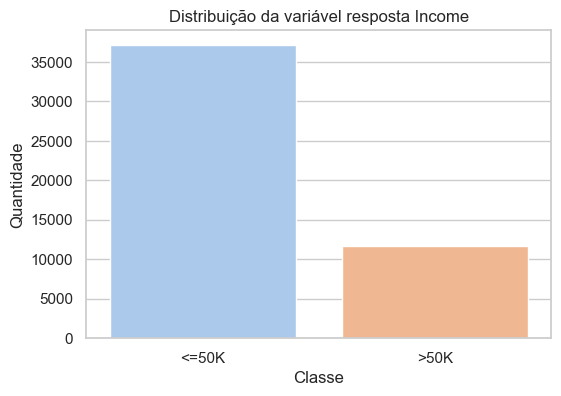

In [21]:

plt.figure(figsize=(6, 4))
sns.barplot(x=income_counts.index, y=income_counts.values, palette="pastel")
plt.title("Distribuição da variável resposta Income")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

### Análise de variáveis Numéricas

Histograma das variáveis numéricas pela faixa de renda

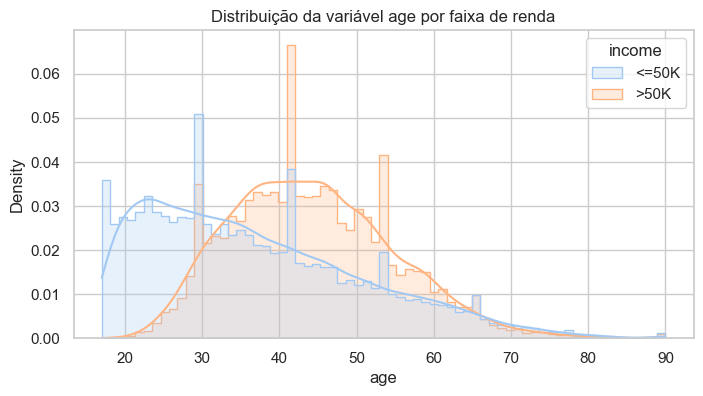

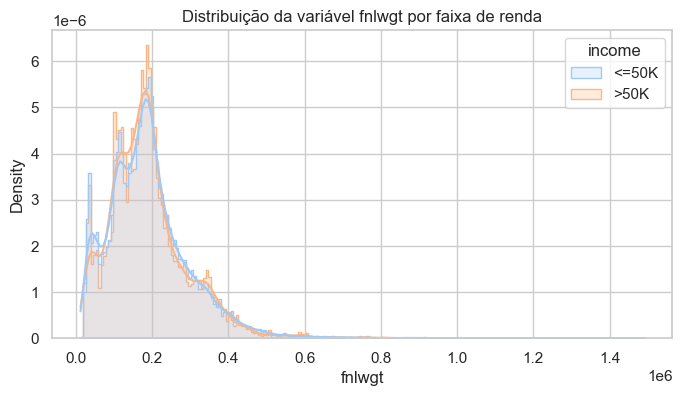

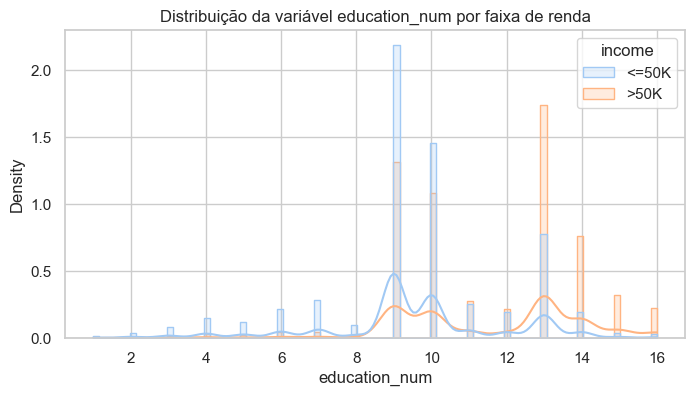

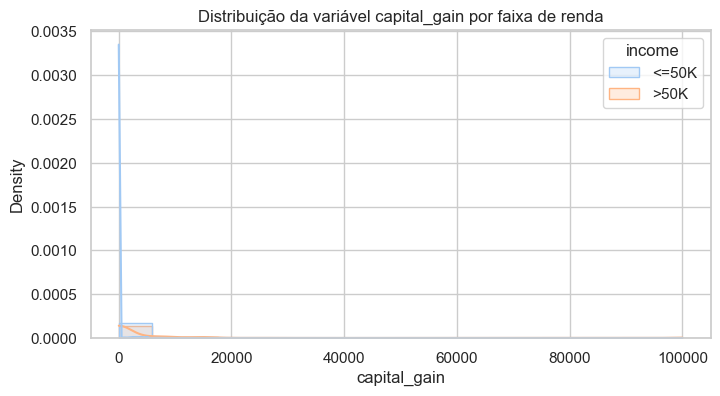

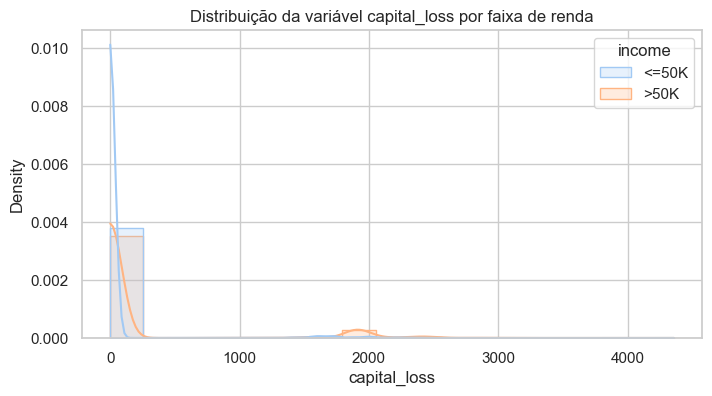

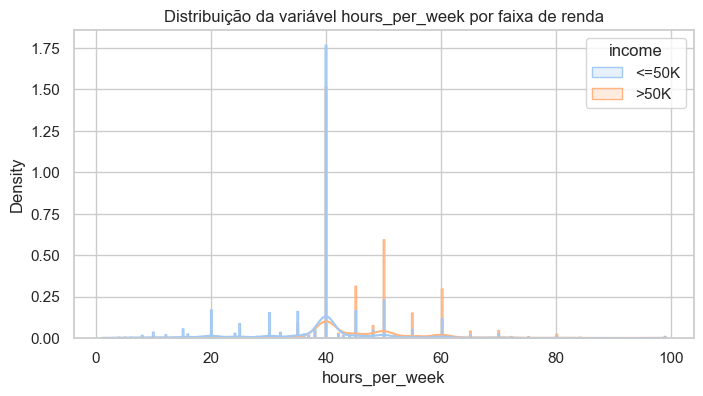

In [24]:

plots = []
for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.histplot(data=data_analysis, x=col, hue='income', kde=True, element='step', stat='density', common_norm=False, ax=ax)
    ax.set_title(f'Distribuição da variável {col} por faixa de renda')
    plots.append(fig)


Pelas análises iniciais exploratórias, é possível identificar que:
-  Distribuição `age`x`income`: Verificando a distribuição da idade pela faixa de renda, a concentração de pessoas com renda maior que 50.000 dolares por ano é de 30 a 70 com simetria e a distribuição de pessoas com renda menor igual a 50.000 dolares por ano tem assimetria positiva.
-  Distribuição `education_num`x `income`: Analisando a quantidade de anos de escolaridade por faixa de renda, é possível verificar que a maior concentração de pessoas com renda maior que 50.000 dolares ocorre com maior quantidade de anos de estudo.
-  Distribuição `hours_per_week`x `income`: Assim como a variável de quantidade de anos de estudo, quanto maior a quantidade de horas de trabalho por semana maior também a renda maior que 50.000 dolares por ano.

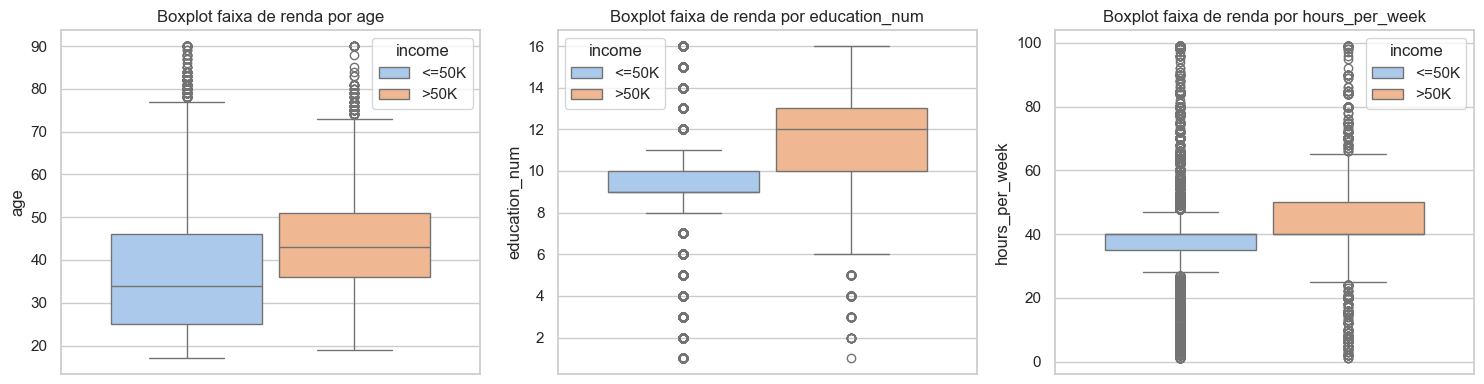

In [26]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4), sharey=False)
cols = ["age", "education_num", "hours_per_week"]

# Loop para popular cada eixo com o respectivo boxplot
for ax, col in zip(axes, cols):
    sns.boxplot(data=data_analysis, y=col,hue='income',gap=.1, ax=ax, palette="pastel")
    ax.set_title(f"Boxplot faixa de renda por {col}")
    ax.set_xlabel("")                # opcional: remove label do eixo x
    ax.set_ylabel(col)               # mostra label no eixo y

plt.tight_layout()
plt.show()

Correlação entre as variáveis

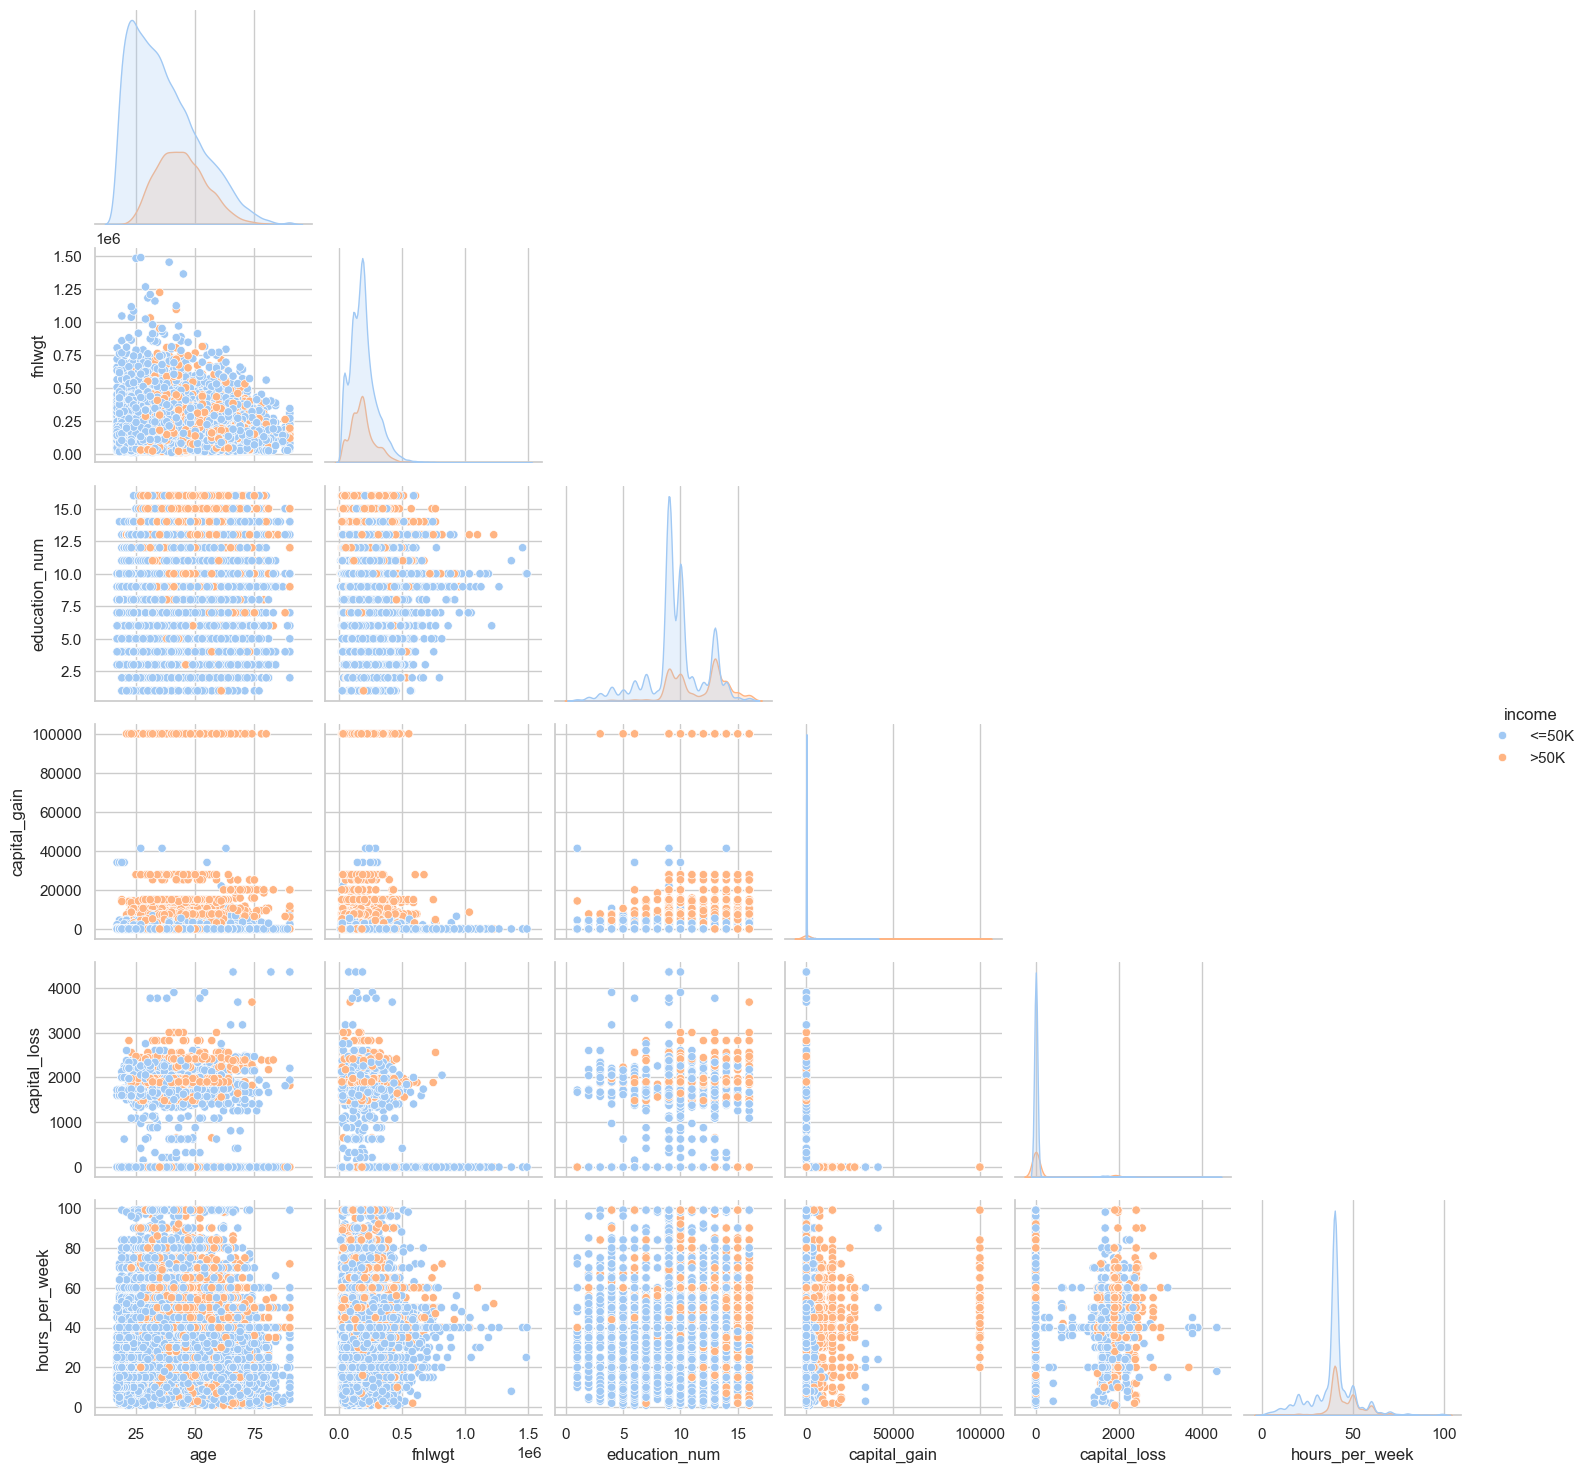

In [28]:
sns.pairplot(data_analysis,
             vars=num_cols,
             hue='income',
             diag_kind='kde',
             corner=True,
             palette='pastel')


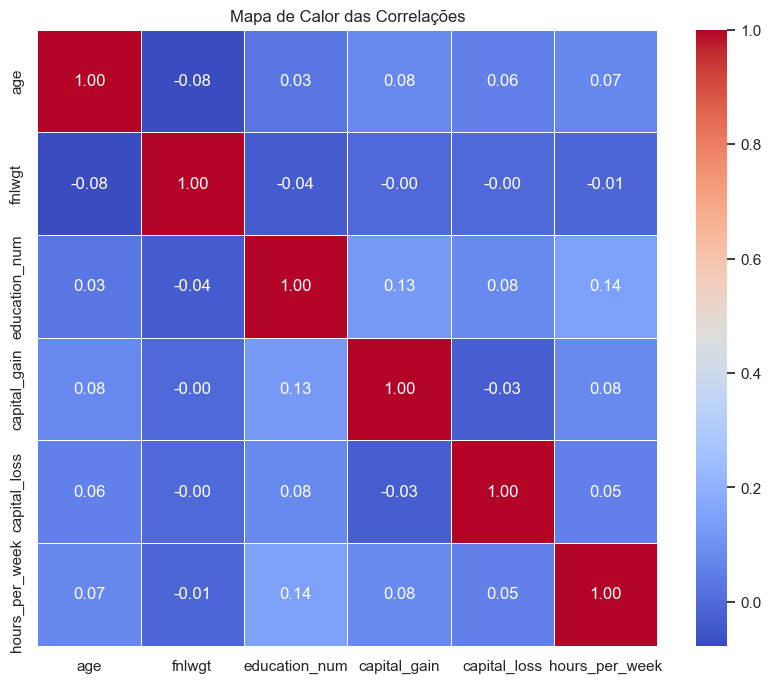

In [29]:
# Calcular correlação entre variáveis numéricas
correlation = data_analysis.corr(numeric_only=True)

# Plotar o heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Mapa de Calor das Correlações")
plt.show()

O pairplot e o heatmap mostram que as correlações lineares entre as variáveis numéricas e com a renda são baixas. Idade se relaciona apenas modestamente com ganho de capital e horas trabalhadas, enquanto `capital_gain` e `capital_loss` raramente coexistem, sugerindo combinar os dois em um saldo líquido. A variável `fnlwgt` não traz relação direta com outras variáveis. Por fim, a análise de correação evidenciou que a associação com as variáveis categoricas ou criação de variáveis a partir de combinações será a maior parte do poder preditivo, além das prováveis relações não lineares.


### Análise de variáveis Categóricas

**Distribuição pelas variaveis categóricas pela faixa de renda**

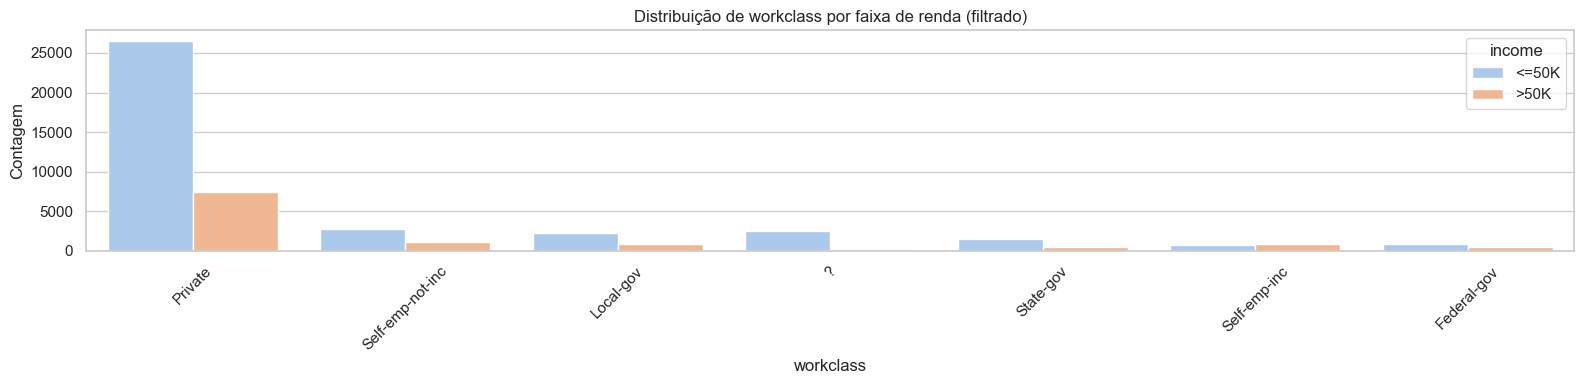

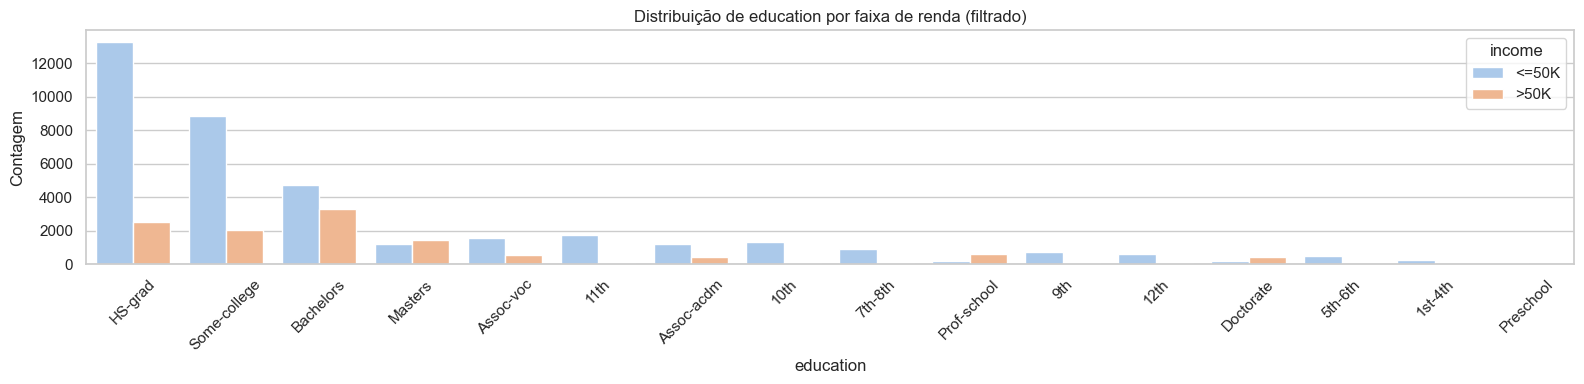

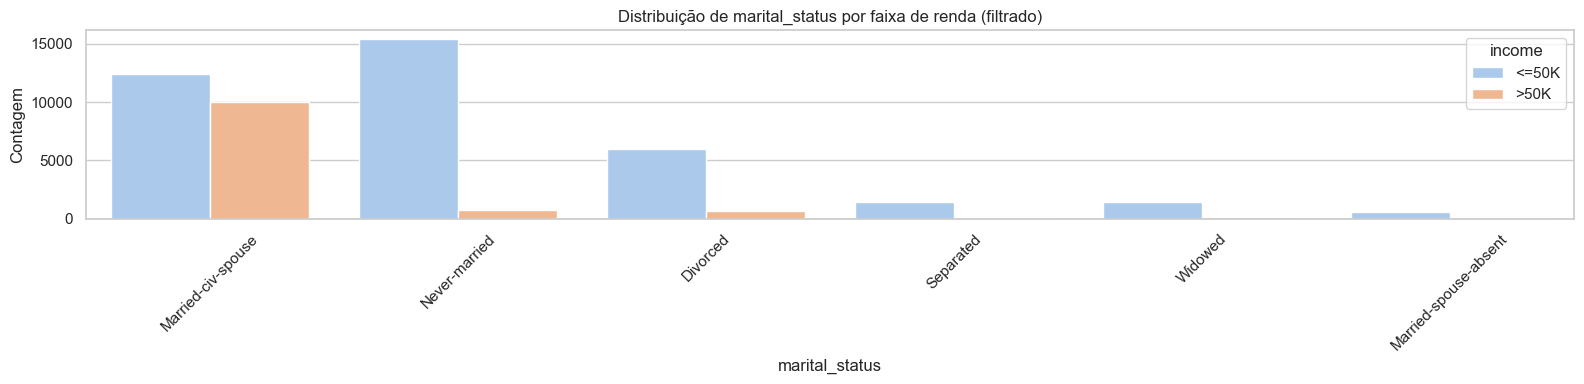

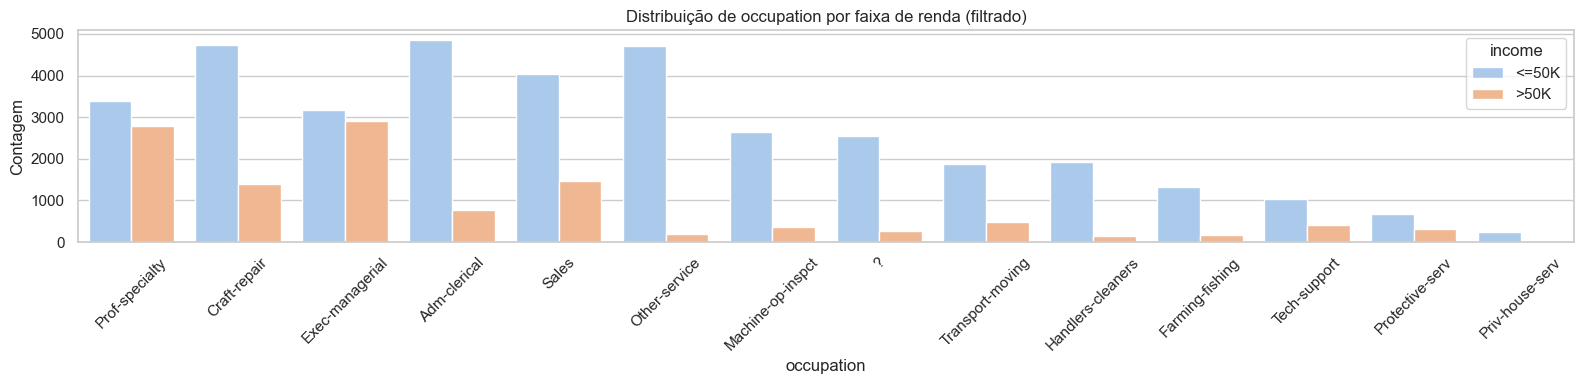

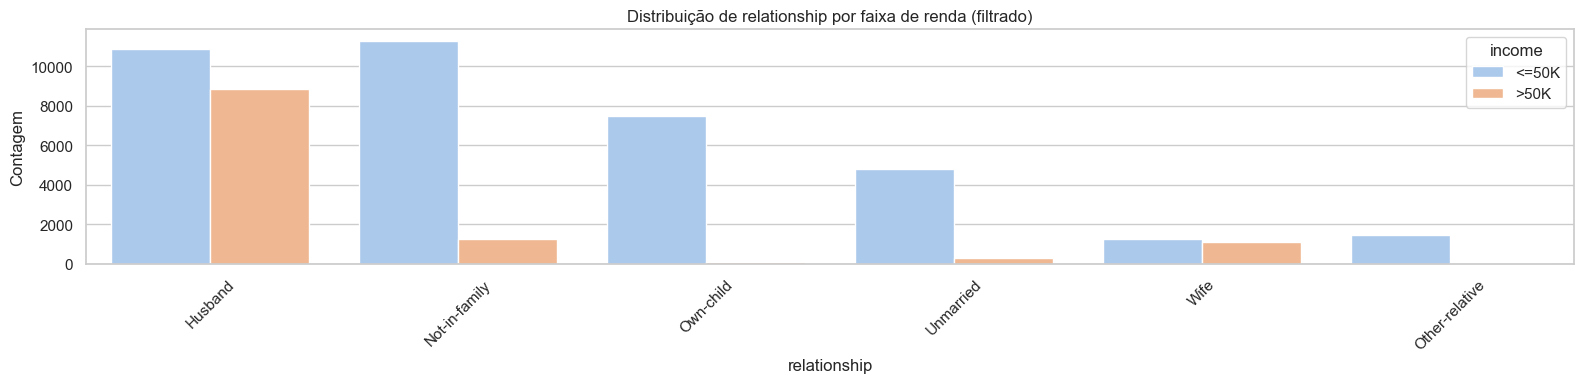

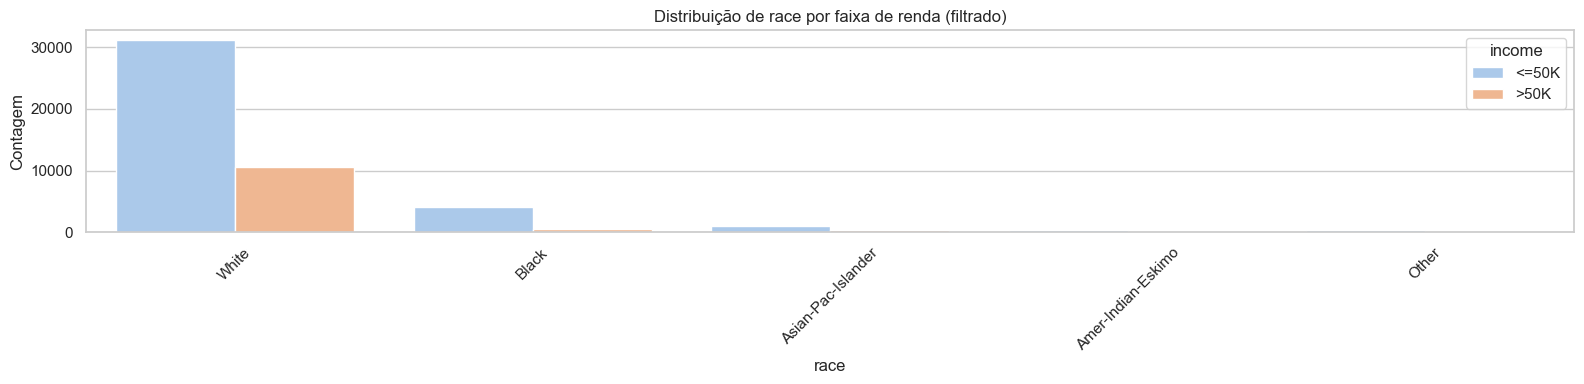

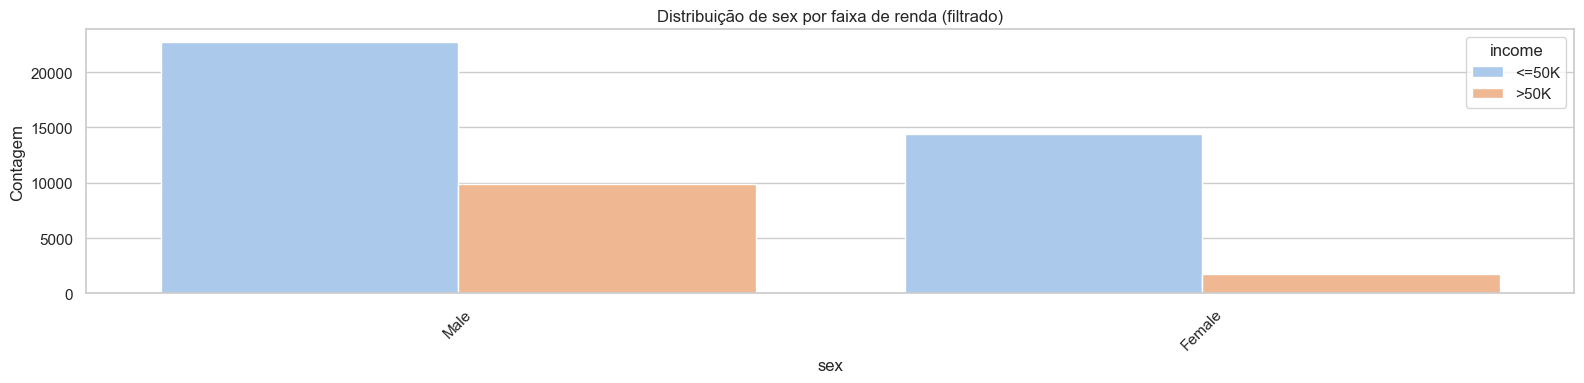

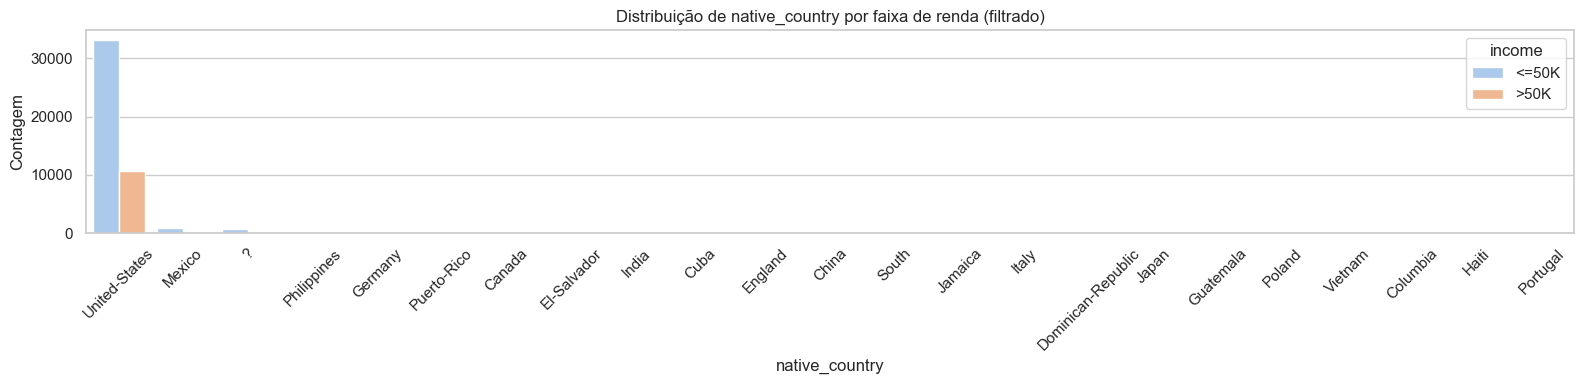

In [33]:
for col in cat_cols:
    
    # Filtrar apenas categorias com pelo menos 50 ocorrência em qualquer classe de income
    crosstab = pd.crosstab(data_analysis[col], data_analysis['income'])
    categorias_validas = crosstab[(crosstab > 50).any(axis=1)].index
    dados_filtrados = data_analysis[data_analysis[col].isin(categorias_validas)]
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.countplot(data=dados_filtrados,
                  x=col,
                  hue='income',
                  palette='pastel',
                  order=dados_filtrados[col].value_counts().index,
                  ax=ax)
    ax.set_title(f'Distribuição de {col} por faixa de renda (filtrado)')
    ax.set_ylabel('Contagem')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plots.append(fig)

Analisando as distribuições das features categóricas, as contagens mostram forte concentração em poucas classes na variável `workclass` é majoritariamente da classe Private, e na variável `education` fica entre HS-grad e Some-college,e na variável `native_country` é dominada pelos EUA enquanto em `race` pelo grupo White. Também é possível verificar um desbalaceamento na variável explicativa `male`, evidenciando a dominancia de dados para o sexo male. Com a pouca representatividade de outras classes e dominância em algumas características não há clara divisão entre faixa de renda pelas variáveis categóricas. 

Porém, analisando a variável `marital_status` evidenciando maior renda acima de 50.000 dolares ao ano a quem possui uma estabilidade domiciliar. Já observando a variavel `education` quem possui bacharel, mestrado, doutorado ou é professor tem maior vantagem em renda. E também, o mesmo efeito se repete em `occupation` ondem cargos administrativos e gerenciais concentram mais ganhos elevados, contrastando com serviços, transporte e manufatura.



**Frequência de ocorrência combinada entre variáveis**

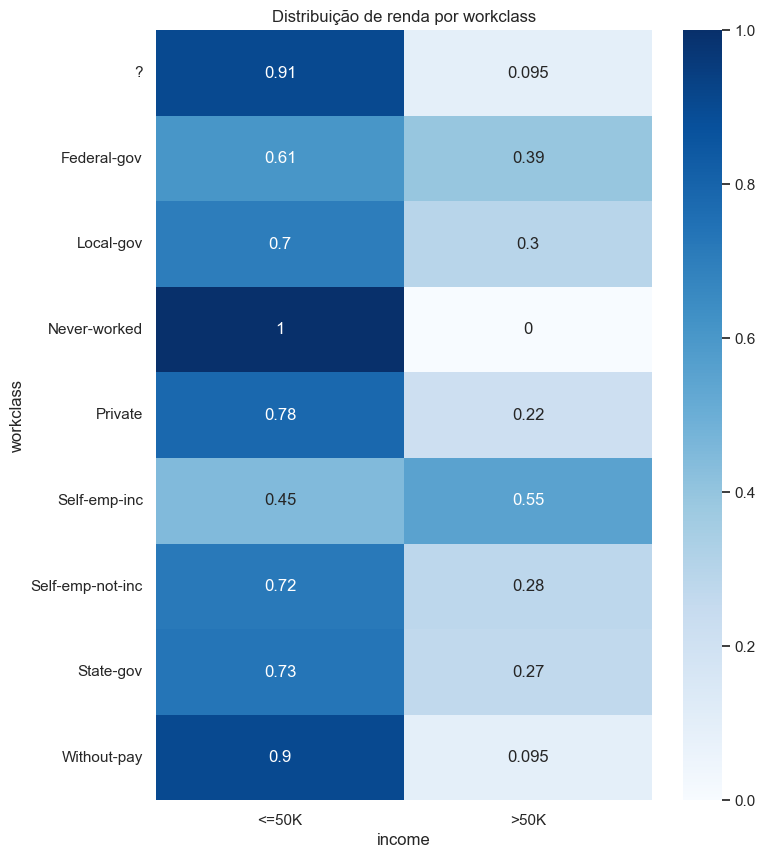

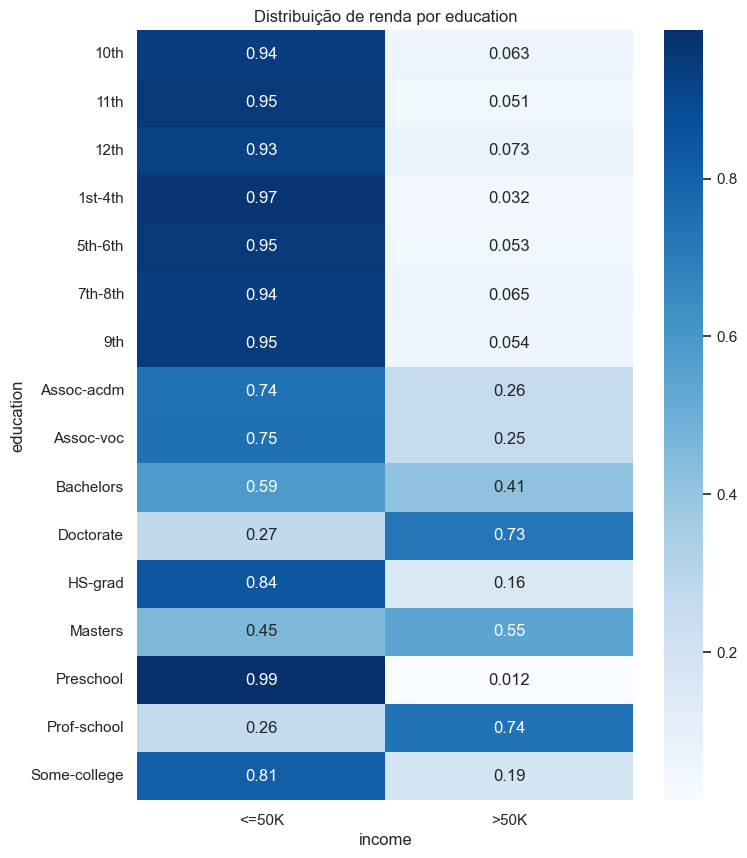

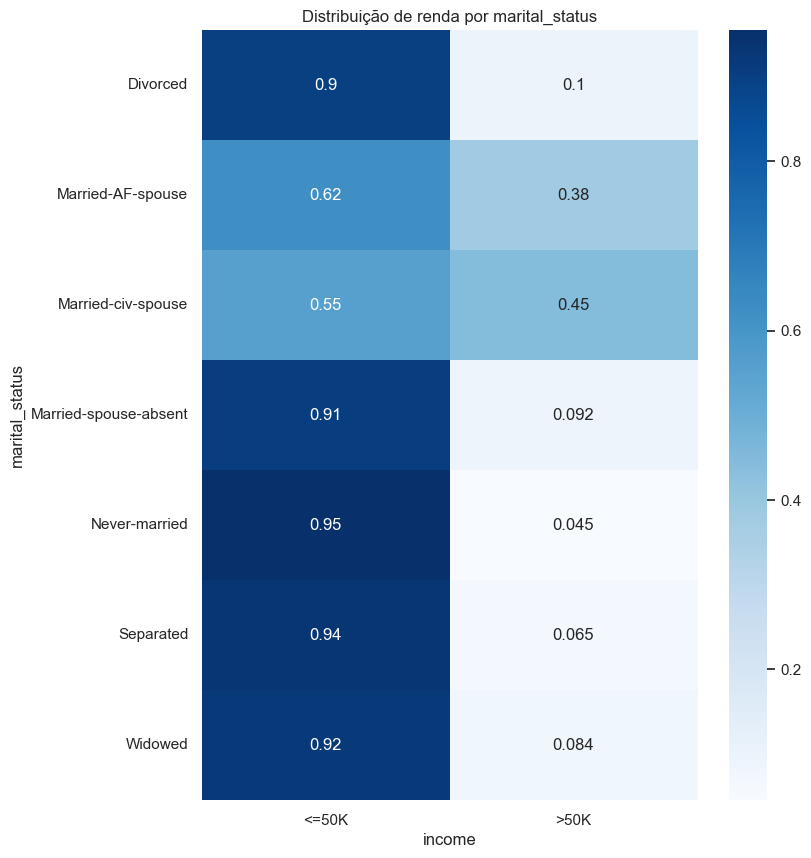

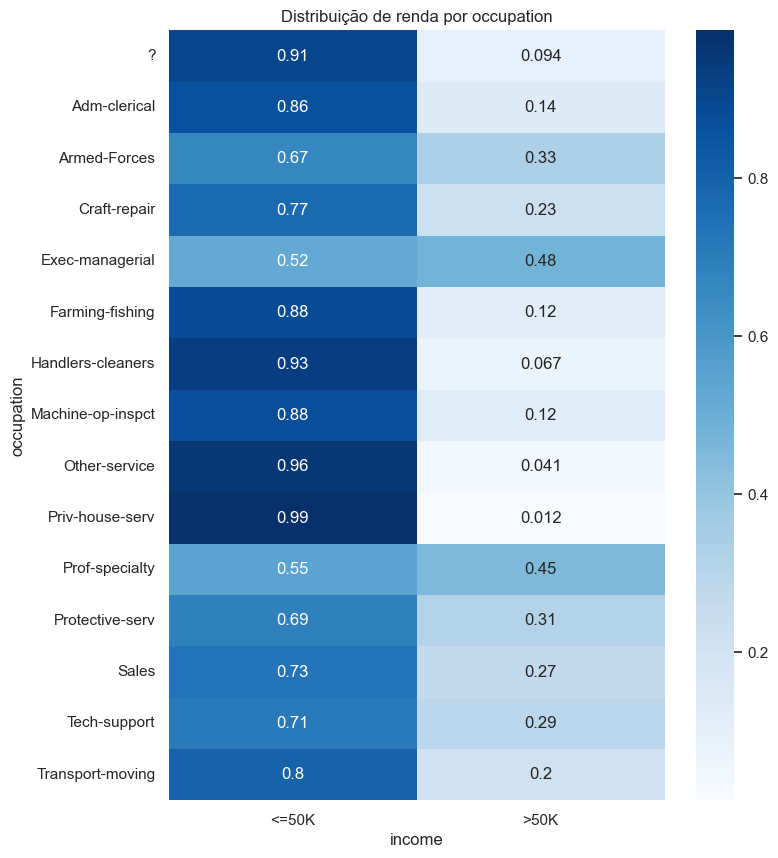

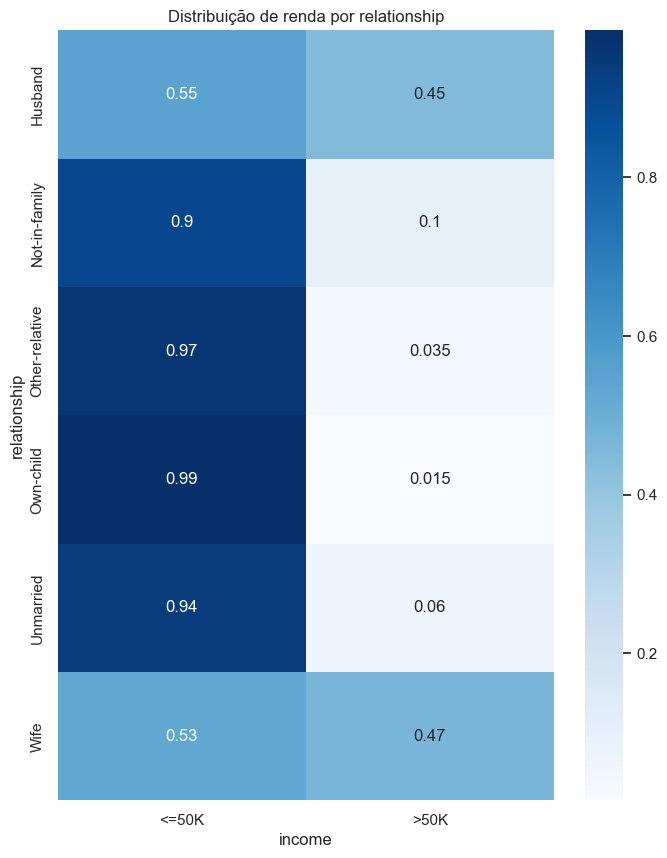

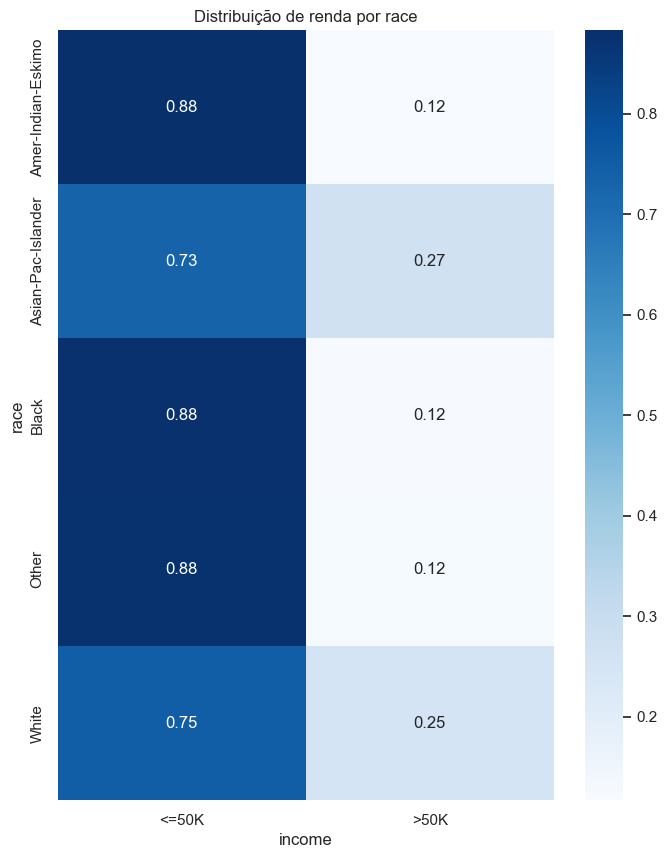

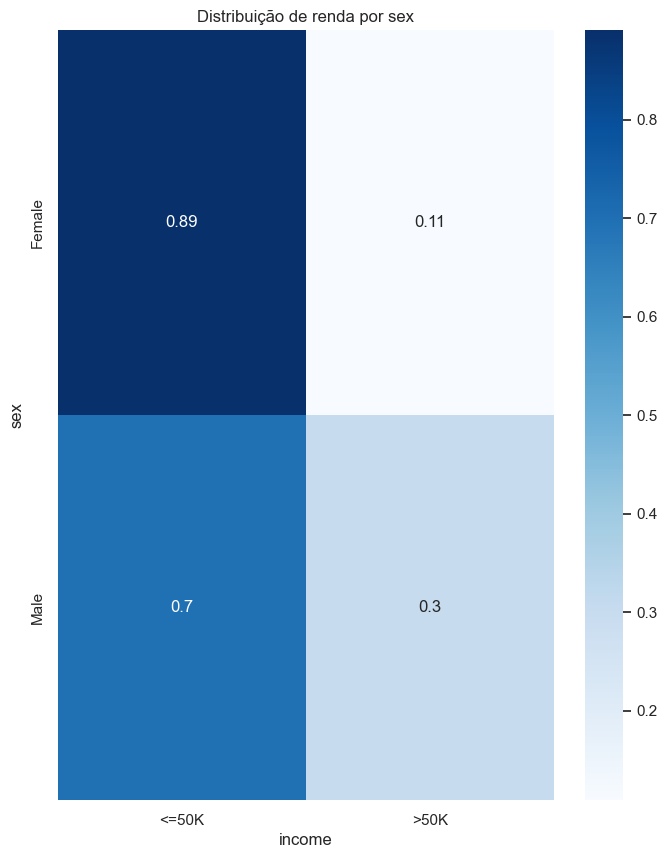

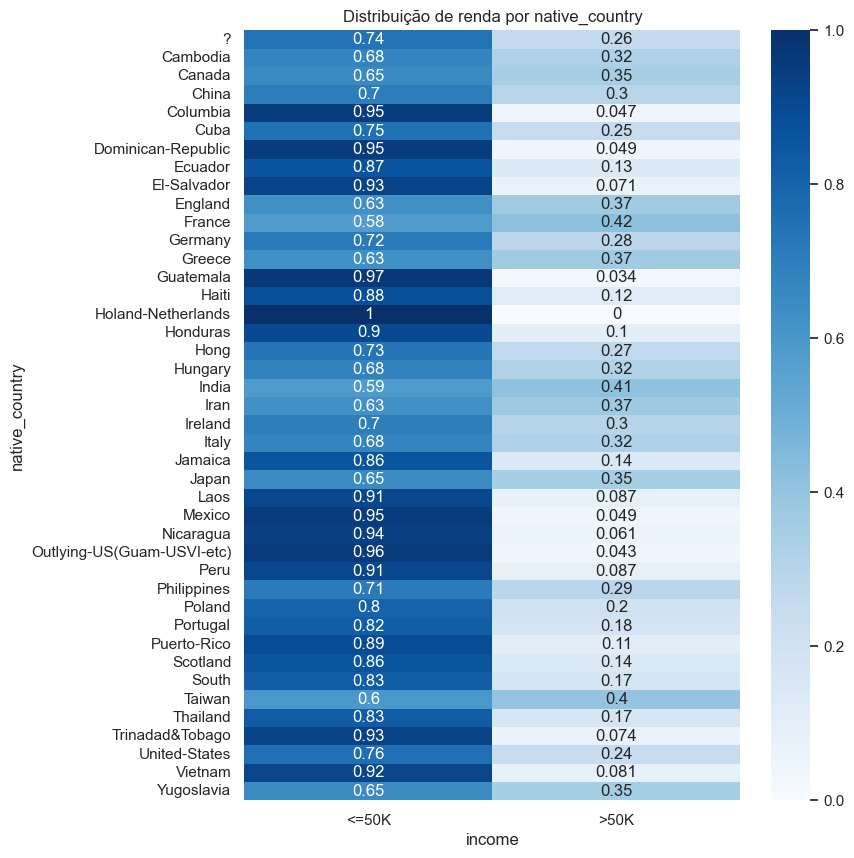

In [36]:
for col in cat_cols:
    fig, ax = plt.subplots(figsize=(8, 10))
    tabela = pd.crosstab(data_analysis[col], data_analysis['income'], normalize='index')
    sns.heatmap(tabela, annot=True, cmap='Blues')
    plt.title(f"Distribuição de renda por {col}")
    plt.show()


Verificando a frequência de ocorrência combinada com a variável de renda, observa-se que pessoas com origem latina e da américa central geralmente não possui renda anual maior que 50.000 dolares, enquanto em outras origens há um equilíbrio maior. Há também uma disparidade em `race` de mais do dobro da proporção de renda maior que 50.000 dolares comparando pessoas Brancas à pessoas Pretas. E quando observamos em `sex`, o sexo masculino com o feminino a disparidade proporcional chega a ser 3 vezes maior. Assim esses contrastes reforçam a checagem de viés na modelagem e cuidado com a utilização de dados sensíveis. 

### Análise por categorização de variáveis numéricas e categóricas

Segmentação por idade

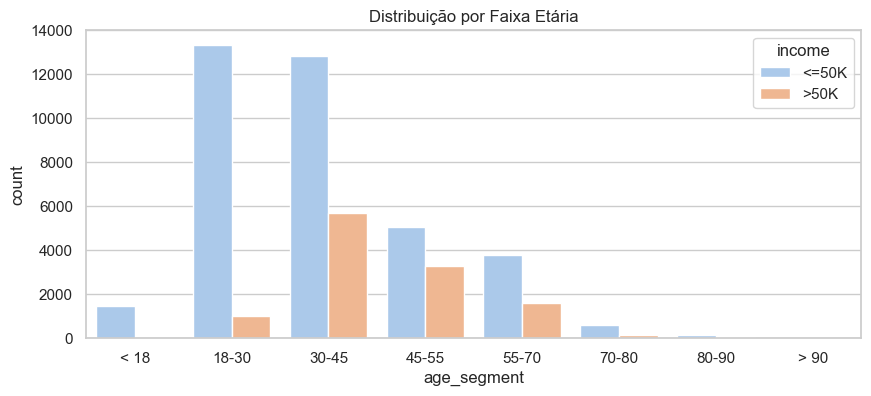

In [40]:
bins_age = [0,18,30,45,55,70,80,90,100]
labels_age = ["< 18", "18-30", "30-45", "45-55","55-70","70-80","80-90", "> 90"]
data_analysis['age_segment'] = pd.cut(data_analysis['age'], bins=bins_age, labels=labels_age)


# Distribuição por segmento de idade
plt.figure(figsize=(10,4))
sns.countplot(data=data_analysis, x='age_segment',hue='income', palette='pastel')
plt.title("Distribuição por Faixa Etária")
plt.show()


Comparando idades agrupadas com renda a dominância dos dados está entre 18 e 45 anos, mas a participação de rendas maior que 50.000 cresce visivelmente a partir dos 30 anos, atinge o auge no grupo de 45-55 e cai depois dos 55. Jovens e idosos têm pouca representatividade  renda elevada.

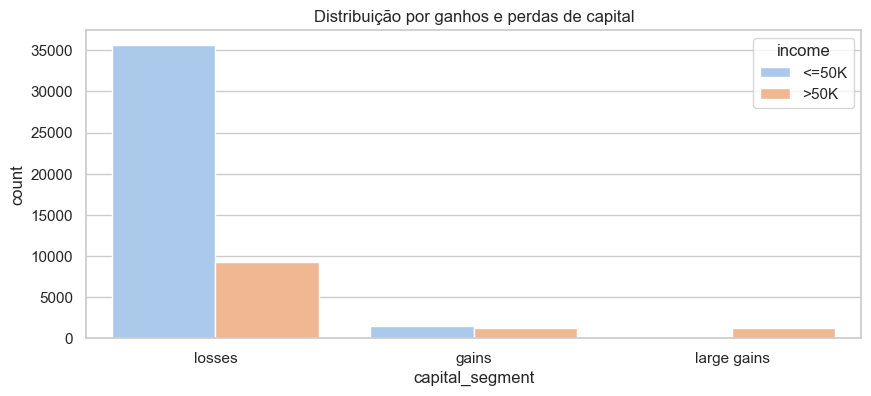

In [42]:
# Construindo uma de capital acumulado
data_analysis['capital'] = data_analysis['capital_gain'] - data_analysis['capital_loss']

# Normalizando a variável e agrupando em categorias de ganhos e perdas
scaler = StandardScaler()
data_analysis['capital_scaled']  = scaler.fit_transform(data_analysis[['capital']] )
bins_capital = [-1,0,1,14]
labels_capital = ["losses","gains","large gains"]
data_analysis['capital_segment'] = pd.cut(data_analysis['capital_scaled'], bins=bins_capital, labels=labels_capital)


plt.figure(figsize=(10,4))
sns.countplot(data=data_analysis, x='capital_segment',hue='income', palette='pastel')
plt.title("Distribuição por ganhos e perdas de capital")
plt.show()

Quase todo o conjunto apresenta perdas ou saldo zero de capital e grandes ganhos de capital ocorrem praticamente só entre quem recebe maior que 50.000 dolares ao ano. Isso sugere que capital_gain é um forte indicador de alta renda.

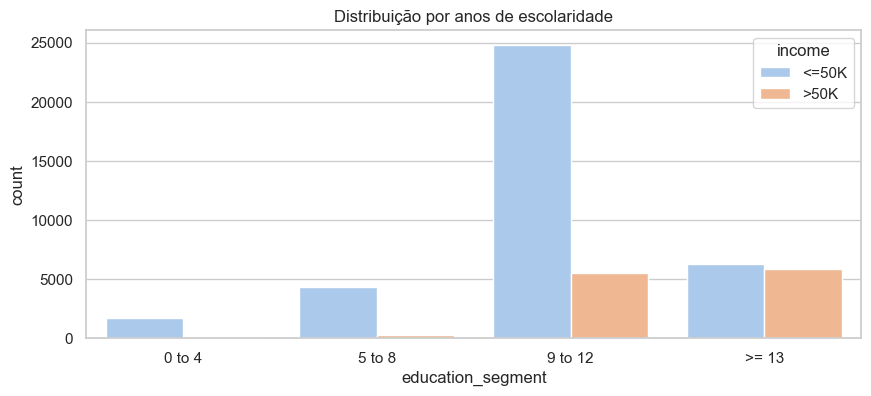

In [44]:
# Categorização de tempo de escolaridade
data_analysis['education_num'] = pd.to_numeric(data_analysis['education_num'], errors='coerce')
data_analysis['education_segment'] = pd.cut(data_analysis['education_num'], bins=[0,4,8,12,17], labels=["0 to 4", "5 to 8", "9 to 12", ">= 13"])


plt.figure(figsize=(10,4))
sns.countplot(data=data_analysis, x='education_segment',hue='income', palette='pastel')
plt.title("Distribuição por anos de escolaridade")
plt.show()

Olhando para escolaridade, é possível notar que ganhos maiores que 50.000 dolares ao ano ocorre quando há uma disposição para alem de 9 anos de estudo

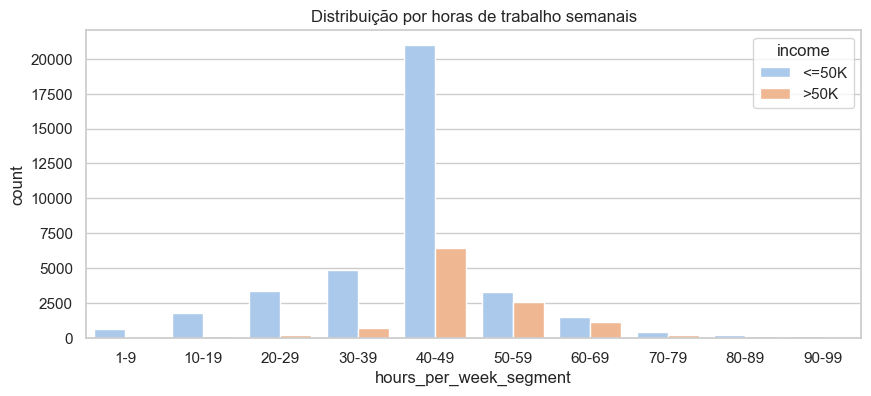

In [46]:
# Categorização de horas semanais

bins_hours = [0,9,19,29,39,49,59,69,79,89,100]
labels_hours = ["1-9", "10-19", "20-29","30-39","40-49","50-59","60-69","70-79","80-89","90-99"]
data_analysis['hours_per_week_segment'] = pd.cut(data_analysis['hours_per_week'], bins=bins_hours, labels=labels_hours)


plt.figure(figsize=(10,4))
sns.countplot(data=data_analysis, x='hours_per_week_segment',hue='income', palette='pastel')
plt.title("Distribuição por horas de trabalho semanais")
plt.show()

A partir de 40 a 49 horas de trabalho semanais referente a uma jornada padrão de trabalho é a onde há maior concentração de dados, sendo que acima de 50 horas de trabalho a contagem começa a cair porém a proporção de salários maiores que 50.000 dolares anuais aumenta devido ao trabalho extra. Jornadas abaixo de 30 horas semanais e acima de 70 horas são raras e quase sempre vinculadas a baixa renda, indicando que tanto emprego parcial quanto cargas extremas não garantem renda elevada.

In [48]:
data_analysis[['education','education_num']].drop_duplicates()

,education,education_num
0,Bachelors,13.0
2,HS-grad,9.0
3,11th,7.0
5,Masters,14.0
6,9th,5.0
10,Some-college,10.0
13,Assoc-acdm,12.0
14,Assoc-voc,11.0
15,7th-8th,4.0
20,Doctorate,16.0


Há colineariadade presente com as variáveis relacionadas a educação, desta forma é necessário no processo de pre-processamento do modelo retirar uma desas variáveis explicativas

### Análise dos dados sobre a ótica de IA Responsável

Entendendo melhor sobre os dados e considerando a Lei Geral de Proteção de Dados, mais especificamente sobre o art. 5º, II da LGPD, entende-se dados **pessoais sensíveis** aqueles que tem origem  `racial` ou `étnica`, `convicção religiosa`, `opinião política`, `filiação a sindicato`, `saúde` ou `vida sexual`, dado `genético` ou `biométrico`. E, portanto, devemos ter tratamento reforçado aos dados considerados de maior risco para a privacidade e para a não-discriminação dos titulares.
 
Desta forma, pensando em uma aplicação prática na vida real, embora as variáveis as variáveis `sex`, `marital_status` e `age` não estejam explícitamente definidas como sensíveis perante a LGPD, diferente da variável `race`, todas elas devem ter um mesmo nível de cuidado em projetos de IA que sensibilizam decisões socioeconômicas.  Por fim, retiraremos estas variáveis para a modelagem final pelos seguintes riscos a serem mitigados:

`race` : Discriminação explícita

`sex` : Viés de gênero

`native_country` : Discriminação por origem

`marital_status` : Prejuízo a pessoas devido a características da vida sexual

`age` : Risco de exclusão etária


Referências utilizadas — IA Responsável

- **BRASIL.** Lei n. 13.709, de 14 de agosto de 2018. Dispõe sobre a proteção de dados pessoais e altera outras leis. *Lei Geral de Proteção de Dados Pessoais (LGPD)*. Diário Oficial da União, 15 ago. 2018. [Link](https://www.planalto.gov.br/ccivil_03/_ato2015-2018/2018/lei/l13709.htm)

- **UNIÃO EUROPEIA.** Regulamento (UE) 2024/1689, de 13 de junho de 2024. *Artificial Intelligence Act*. *Official Journal of the European Union*, 12 jul. 2024. [Link](https://eur-lex.europa.eu/eli/reg/2024/1689/oj)

- **OECD.** Recommendation of the Council on Artificial Intelligence. OECD Legal Instrument No. OECD/LEGAL/0449, maio 2019. [Link](https://legalinstruments.oecd.org/en/instruments/OECD-LEGAL-0449)

- **NIST (U.S. Department of Commerce).** *Artificial Intelligence Risk Management Framework (AI RMF 1.0)*. NIST AI 100-1, jan. 2023. [Link](https://doi.org/10.6028/NIST.AI.100-1)



# Treinamento do modelo

In [53]:
# Base de dados de treinamento e teste
url_train = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
url_test  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"


#### Carregando os dados


A partir das URL's do repositório da UCI, importaremos as base de dados tanto de treinamento quanto de teste para realizar o treinamento dos modelos e escolha dos melhores hiperparâmetros. 

In [56]:
# Colunas a serem utilizadas
col_names = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race","sex",
    "capital_gain","capital_loss","hours_per_week","native_country","income"
]


#train = pd.read_csv(url_train, names=col_names, skipinitialspace=True)
#test  = pd.read_csv(url_test , names=col_names, skipinitialspace=True)

train = pd.read_csv('Adult/adult.data', names=col_names, skipinitialspace=True)
test  = pd.read_csv('Adult/adult.test' , names=col_names, skipinitialspace=True)

test = test.drop(index=0).reset_index(drop=True)


Adequando os dados, limpando-os e convertendo colunas para formatação numérica

In [58]:

# Retirar ruído da variável resposta
train['income'] = train['income'].apply(lambda x: x.replace('.',''))

# cast para tipo numérico das variaveis: idade, numero de anos de escolaridade
for col in ['age','education_num','hours_per_week']:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')
    


#### Pré-processamento dos dados para modelagem

Primeiramente eliminaremos duplicatas se houver garantindo dados únicos para tanto treino e teste. Em seguida, tranformamos a variável resposta para binário, permitindo ao modelo reconhecer padrões com base nas features explicativas. 

Também foi criada variáveis por meio de feature engineering representando o ganho líquido de capital(`capital_net`), carga horária semanal como proporção de uma jornada padrão de 40 horas semanais(`hours_relative`). Além disso, devido após a análise por IA Responsável as variáveis `age`, `race`, `sex`, `native_country` e `marital_status` carregam fortes conotações demográficas que podem induzir discriminação algorítmica. Ao excluí-las, reduzimos o risco de viés injusto, facilitamos a conformidade com regulações e focamos em atributos que explicam renda sem recorrer a características pessoais sensíveis.

In [61]:

# Drop duplicatas
train = train.drop_duplicates().reset_index(drop=True)
test = test.drop_duplicates().reset_index(drop=True)

# Adequando target
train['income']= train['income'].map({'<=50K': 0, '>50K': 1})
test['income']=test['income'].map({'<=50K': 0, '>50K': 1})

# Feature Engineering
train['capital_net'] = train['capital_gain'] - train['capital_loss']
train['hours_relative'] = train['hours_per_week'] / 40

test['capital_net'] = test['capital_gain'] - test['capital_loss']
test['hours_relative'] = test['hours_per_week'] / 40

# Removendo variáveis que podem induzir discriminação
train = train.drop(['education','age','race','sex','native_country','marital_status','relationship'], axis=1) 
test = test.drop(['education','age','race','sex','native_country','marital_status','relationship'], axis=1) 


Selecionando as variáveis categóricas e numéricas para auxiliar a imputação de dados via um pipeline de processamento

In [63]:
num_cols = [ 'education_num', 'fnlwgt', 'hours_per_week', 'capital_gain', 'capital_loss', 'capital_net', 'hours_relative']
cat_cols = [col for col in train.select_dtypes(include='object').columns if col != 'income']


Dividindo os dados entre treino e teste semarando as variáveis explicativas da variável resposta

In [65]:
X_train = train.drop('income', axis=1)
y_train = train['income']

X_test = train.drop('income', axis=1)
y_test = train['income']


Após a seperação dos dados dando continuidade ao pré-processamento das variráveis utilizando um pipeline encadeando todas as etapas de um fluxo de processamento de aprendizado com tranformação dos dados sem vazamento de informação, tratamento de valores faltantes com preenchimento pela mediana para variáveis numéricas e moda para dados categóricos. Além disso, aplicando normalização de dados e também one-hot encoding tranformando as variáveis categóricas em binárias facilitando o reconhecimento de padrão. 

Isso garante que o mesmo pré-processamento aplicado no treino seja reaplicado no teste sem vazamento de informação, e também, permite ajustar hiperparâmetros de todo o fluxo com ferramentas como GridSearchCV ou Optuna de forma coesa com uma interface para fit/predict.

In [67]:

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])


Em seguida, definiremos a função objetivo do otimizador de hiperparâmetros Optuna, e a cada tentativa completa da busca de hiperparâmetros, gera-se as métricas de desempenho registrando ao algoritmo de otimização. Evidenciando assim, possíveis caminhos para as próximas combinaçôes de hiperarâmetros por meio de uma busca bayseana fornecendo o feedback necessário para que as próximas tentativas explorem combinações mais promissoras.

Escolhi 4 modelos de classificação, sendo eles :
- RandomForest
-  XGBoost
-  LightGBM
-  SVM

Portanto, na otimização dos hiperparâmetros, define-se um pipeline englobando o pré-processamento antes citado e também um balanceamento de classes pelo algoritmo SMOTE (Devido a desproporção das classes observado na análise exploratória) e por fim aplicando o modelo. Em seguida é observado o desempenho do algoritmo por validação cruzada usando a área embaixo da curva ROC como métrica de avaliação do algoritmo, buscando maximizar a métrica.  Ao fim, Optuna reporta a combinação de hiperparâmetros com melhor AUC-ROC.

In [69]:
def objective(trial):
    # definindo modelos
    model_name = trial.suggest_categorical('model', ['RandomForest', 'XGBoost', 'LightGBM','SVM'])

    # definindo hiperparametros de cada modelo a ser selecionado
    if model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('rf_n_estimators', 50, 300, step=50),
            'max_depth': trial.suggest_int('rf_max_depth', 3, 50),
            'min_samples_split': trial.suggest_int('rf_min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('rf_min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('rf_max_features', ['sqrt', 'log2']),
            'bootstrap': trial.suggest_categorical('rf_bootstrap', [True, False]),
            'class_weight': 'balanced'  # balanceamento interno
        }
        model = RandomForestClassifier(**params, random_state=42)

    elif model_name == 'XGBoost':
        scale_pos_weight = trial.suggest_float('xgb_scale_pos_weight', 0.5, 10.0)
        params = {
            'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 300, step=50),
            'max_depth': trial.suggest_int('xgb_max_depth', 3, 50),
            'learning_rate': trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True),
            'gamma': trial.suggest_float('xgb_gamma', 0, 5),
            'subsample': trial.suggest_float('xgb_subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('xgb_reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('xgb_reg_lambda', 0.0, 5.0),
            'scale_pos_weight': scale_pos_weight
        }
        model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss', random_state=42)

    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('lgb_n_estimators', 50, 300, step=50),
            'max_depth': trial.suggest_int('lgb_max_depth', 3, 50),
            'learning_rate': trial.suggest_float('lgb_learning_rate', 0.01, 0.3, log=True),
            'num_leaves': trial.suggest_int('lgb_num_leaves', 20, 150),
            'min_child_samples': trial.suggest_int('lgb_min_child_samples', 5, 100),
            'subsample': trial.suggest_float('lgb_subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('lgb_colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('lgb_reg_alpha', 0.0, 5.0),
            'reg_lambda': trial.suggest_float('lgb_reg_lambda', 0.0, 5.0),
            'is_unbalance': True  # balanceamento automático
        }
        model = lgb.LGBMClassifier(**params, random_state=42)

    elif model_name == 'SVM':
        params = {
            'C': trial.suggest_float('svm_C', 1e-3, 1e3, log=True),
            'kernel': trial.suggest_categorical('svm_kernel', ['linear', 'rbf', 'poly']),
            'gamma': trial.suggest_categorical('svm_gamma', ['scale', 'auto']),
            'class_weight': 'balanced'
        }
        if params['kernel'] == 'poly':
            params['degree'] = trial.suggest_int('svm_degree', 2, 5)

        model = SVC(**params, probability=True, random_state=42)

    # Pipeline com balanceamento (SMOTE) + pre-processamento + modelo
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

    # Validação cruzada interna

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = []
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        fold_auc = roc_auc_score(y_val, pipeline.predict_proba(X_val)[:, 1])
        scores.append(fold_auc)

        #  reporta o valor parcial ao Optuna
        trial.report(fold_auc, step=step)

        #  aborta a tentativa dado a avaliação do pruner
        if trial.should_prune():
            raise TrialPruned()       

    
    return np.mean(scores)

# salva os logs das tentativas com métricas, tempo de treinamento, e parametros utilizados pelos modelos
def dump_trials(study, trial):
    df_metrics = study.trials_dataframe(attrs=("number", "value", "params", "state","duration"))
    df_metrics.to_csv("log_opt/trials_log_v2.csv", index=False)


# Execução do Optuna
pruner = SuccessiveHalvingPruner(min_resource=1,  
                                 reduction_factor=3,  
                                 min_early_stopping_rate=1)

study = optuna.create_study(direction='maximize', pruner=pruner)
study.optimize(objective, n_trials=50,n_jobs=-1, callbacks=[dump_trials], timeout=1800)


df_metrics = pd.read_csv('log_opt/trials_log_v2.csv')
display(df_metrics)
print("Melhor configuração:", study.best_params)
print("Melhor score de ROC AUC:", study.best_value)

[I 2025-06-23 00:56:39,994] A new study created in memory with name: no-name-b8009887-a133-4e35-9ebb-7c5c3d7a2ba0
[I 2025-06-23 00:56:55,072] Trial 3 finished with value: 0.7796566804656131 and parameters: {'model': 'LightGBM', 'lgb_n_estimators': 100, 'lgb_max_depth': 14, 'lgb_learning_rate': 0.09062881279571665, 'lgb_num_leaves': 96, 'lgb_min_child_samples': 80, 'lgb_subsample': 0.6217320225834628, 'lgb_colsample_bytree': 0.8673712293842359, 'lgb_reg_alpha': 2.230196159484732, 'lgb_reg_lambda': 4.270937552636886}. Best is trial 3 with value: 0.7796566804656131.
[I 2025-06-23 00:57:17,173] Trial 0 pruned. 
[I 2025-06-23 00:57:23,206] Trial 1 finished with value: 0.7487508516660737 and parameters: {'model': 'XGBoost', 'xgb_scale_pos_weight': 7.103795283250929, 'xgb_n_estimators': 300, 'xgb_max_depth': 32, 'xgb_learning_rate': 0.1929225507877494, 'xgb_gamma': 2.2952541832700506, 'xgb_subsample': 0.6242186313918242, 'xgb_colsample_bytree': 0.9669195528220316, 'xgb_reg_alpha': 1.044955244

,number,value,params_lgb_colsample_bytree,params_lgb_learning_rate,params_lgb_max_depth,params_lgb_min_child_samples,params_lgb_n_estimators,params_lgb_num_leaves,params_lgb_reg_alpha,params_lgb_reg_lambda,params_lgb_subsample,params_model,params_rf_bootstrap,params_rf_max_depth,params_rf_max_features,params_rf_min_samples_leaf,params_rf_min_samples_split,params_rf_n_estimators,params_svm_C,params_svm_degree,params_svm_gamma,params_svm_kernel,params_xgb_colsample_bytree,params_xgb_gamma,params_xgb_learning_rate,params_xgb_max_depth,params_xgb_n_estimators,params_xgb_reg_alpha,params_xgb_reg_lambda,params_xgb_scale_pos_weight,params_xgb_subsample,state,duration
0,0,0.694367,0.540220,0.093650,24.0,70.0,200.0,77.0,0.928090,2.095441,0.667708,LightGBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED,0 days 00:00:37.177201
1,1,0.748751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XGBoost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.966920,2.295254,0.192923,32.0,300.0,1.044955,0.722774,7.103795,0.624219,COMPLETE,0 days 00:00:43.210137
2,2,0.797489,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RandomForest,True,50.0,sqrt,7.0,18.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE,0 days 00:01:52.278093
3,3,0.779657,0.867371,0.090629,14.0,80.0,100.0,96.0,2.230196,4.270938,0.621732,LightGBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE,0 days 00:00:15.076158
4,4,0.828441,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RandomForest,True,36.0,log2,9.0,2.0,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE,0 days 00:00:48.104116
5,5,0.662261,0.569897,0.094610,45.0,18.0,250.0,53.0,3.867360,2.624736,0.938236,LightGBM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED,0 days 00:00:19.884443
6,6,0.834478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RandomForest,False,15.0,log2,9.0,18.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED,0 days 00:01:41.881650
7,7,0.828518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RandomForest,False,21.0,sqrt,9.0,12.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED,0 days 00:02:13.440098
8,8,0.821420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RandomForest,False,11.0,log2,9.0,16.0,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE,0 days 00:01:14.228557
9,9,0.816037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RandomForest,True,49.0,log2,6.0,12.0,200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,COMPLETE,0 days 00:01:07.294164


Melhor configuração: {'model': 'XGBoost', 'xgb_scale_pos_weight': 3.4901699236854684, 'xgb_n_estimators': 100, 'xgb_max_depth': 6, 'xgb_learning_rate': 0.11683421378792522, 'xgb_gamma': 2.2846252215627083, 'xgb_subsample': 0.9238358498683521, 'xgb_colsample_bytree': 0.5352607549122335, 'xgb_reg_alpha': 0.18275662179520702, 'xgb_reg_lambda': 2.9829952463877496}
Melhor score de ROC AUC: 0.8483945490513205


Obs: O mecanismo de pruner faz comque as tentativas ou `trials` ruins são eliminados cedo, liberando tempo de computação para os mais promissores, enquanto os melhores recebem gradativamente mais orçamento.

#### Avaliando desempenho em tempo de treinamento do Modelo

In [72]:
# 2. Basic overview
print("=== Shape of DataFrame ===")
print(df_metrics.shape)

# 3. Preview the first 20 rows in an interactive table
tools.display_dataframe_to_user("Preview of trials_log.csv (first 20 rows)", df_metrics.head(20))


=== Shape of DataFrame ===
(17, 33)
Preview of trials_log.csv (first 20 rows)


Loading ITables v2.4.2 from the internet... (need help?)


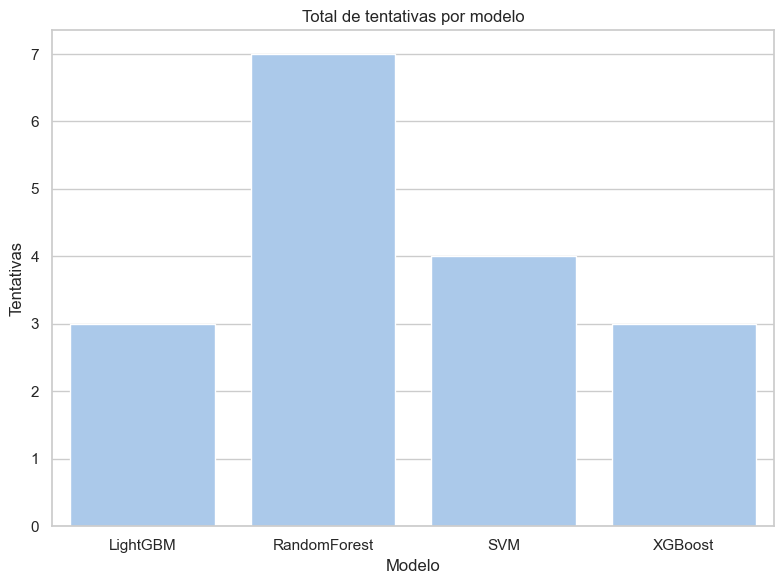

In [73]:
# Total de trials por modelo
total_trials = (df_metrics.groupby("params_model").size().reset_index(name="total_trials"))

plt.figure(figsize=(8, 6))
sns.barplot(data=total_trials,x="params_model",y="total_trials",)
plt.title("Total de tentativas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Tentativas")
plt.tight_layout()
plt.show()

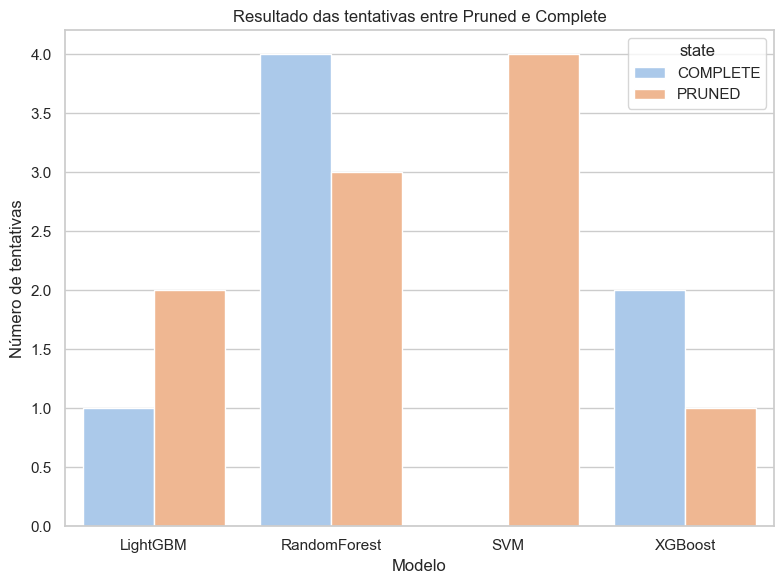

In [74]:
# Gráfico das tentativas de modelos completas e abortadas
counts_state = df_metrics.groupby(["params_model", "state"]).size().reset_index(name="count")

plt.figure(figsize=(8, 6))
sns.barplot(data=counts_state,x="params_model",y="count",hue="state",)
plt.title("Resultado das tentativas entre Pruned e Complete")
plt.xlabel("Modelo")
plt.ylabel("Número de tentativas")
plt.tight_layout()
plt.show()


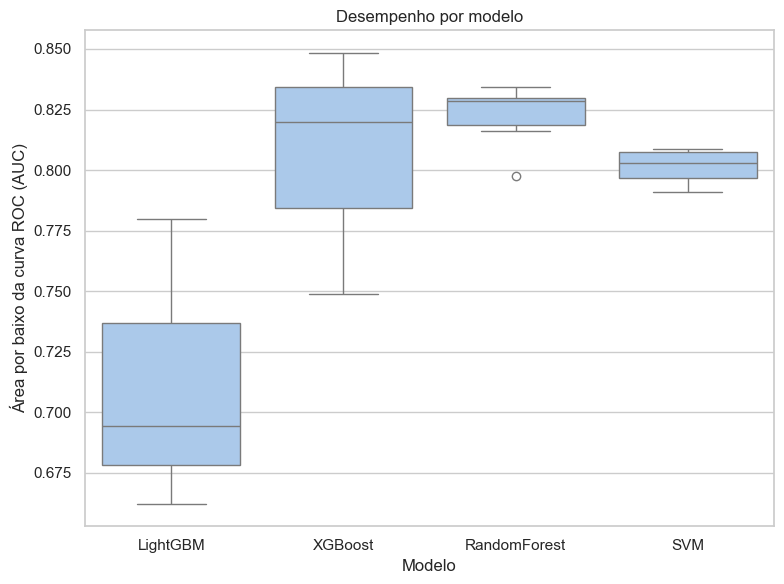

In [75]:
# Distribuição de performance (value) por modelo
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_metrics, x="params_model", y="value")
plt.title("Desempenho por modelo")
plt.xlabel("Modelo")
plt.ylabel("Área por baixo da curva ROC (AUC)")
plt.tight_layout()
plt.show()


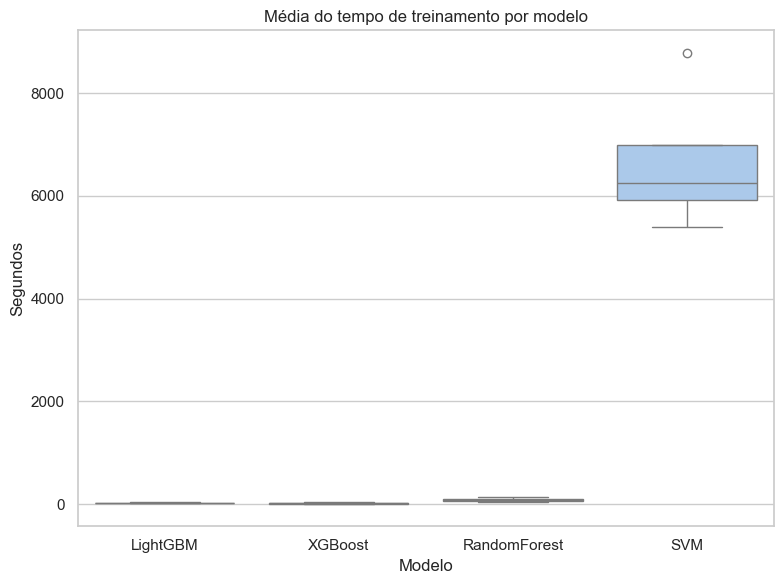

In [76]:
# Duração média de treino por modelo
df_metrics["duration_sec"] = pd.to_timedelta(df_metrics["duration"]).dt.total_seconds()
mean_duration = df_metrics.groupby("params_model")["duration_sec"].mean().reset_index()

# Distribuição do tempo de processamento por modelo

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_metrics, x="params_model", y="duration_sec")
plt.title("Média do tempo de treinamento por modelo")
plt.xlabel("Modelo")
plt.ylabel("Segundos")
plt.tight_layout()
plt.show()


Olhando o panorama geral da busca de hiperparâmetros com o otimizador Optuna juntamente com validação cruzada para garantir generalidade do reconhecimento de padrões por toda a base deixando as busca mais robusta, podemos notar que o modelo XGBoost foi o que melhor evidenciou um desempenho por meio da AUC e também  evidenciou menor tempo de treinamento junto com o LightGBM. 

Entretanto o SVM apesar de conseguir separar dados experimentando diferentes tipos de kernels para dados não lineares também em busca de maximizar a margem entre as classes respostas com o melhor hiperplano, apesar de ter um desempenho alto variado entre 0.77-0.81 de desempenho, seu tempo de treinamento foi significativamente maior acima dos 100 minutos. 

 A Random forest, obteve desempenho similar ao XGBoost e com baixa variância dos resultado acima de  0.8 de AUC, porém com grande número de tentativas abortadas devido ao mecanismo de pruner identificar experimentos não tão promissores e aborta-las deixando recurso computacional disponível para as mais promissoras.
 
Em resumo, as análises contruídas de desempenho evidenciam que o XGBoost mostrou um desempenho bom mas com alta variância assim como o LightGBM e treinamento rápido, apesar de todas as soluções possuírem bom desempenho pelo AUC.


#### Treinamento do modelo final

Tendo os melhores hiperparâmetros definidos por uma busca otimizada de forma a encontrar aquele conjunto que generalize bem o treinamento de um classificador pela respectiva base de dados. É selecionado o modelo e os hiperparâmetros, agora para treinar os parâmetros do modelo final aproveitando todas as intâncias disponíveis na base de treinamento

In [80]:
# Dicionário base para reconstrução
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

prefix_map = {
    'RandomForest': 'rf_',
    'XGBoost': 'xgb_',
    'LightGBM': 'lgb_',
    'CatBoost': 'cat_',
    'SVM': 'svm_'
}

In [81]:
# Nome do melhor modelo
final_model_name = study.best_params['model']
final_model_name

'XGBoost'

In [82]:
# Extração dos parâmetros do modelo
prefix = prefix_map[final_model_name]
final_params = {
    k.replace(prefix, ''): v
    for k, v in study.best_params.items()
    if k.startswith(prefix)
}
final_params

{'scale_pos_weight': 3.4901699236854684,
 'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.11683421378792522,
 'gamma': 2.2846252215627083,
 'subsample': 0.9238358498683521,
 'colsample_bytree': 0.5352607549122335,
 'reg_alpha': 0.18275662179520702,
 'reg_lambda': 2.9829952463877496}

In [83]:
# Parâmetros fixos para balanceamento
if final_model_name == 'RandomForest':
    final_params['class_weight'] = 'balanced'
elif final_model_name == 'SVM':
    final_params['class_weight'] = 'balanced'
elif final_model_name == 'LightGBM':
    final_params['is_unbalance'] = True
elif final_model_name == 'XGBoost':
    final_params['scale_pos_weight'] = study.best_params.get('xgb_scale_pos_weight', 1.0)


Por fim, treinamos o modelo definitivo e o serializamos com Pickle, convertendo o modelo em um objeto em bytes. Isso permite armazenar o modelo treinado em disco e, sempre que necessário, recarregá-lo rapidamente para realizar inferência, sem repetir todo o processo de treinamento.

In [85]:
# Reconstruir modelo
final_model = models[final_model_name]
final_model.set_params(**final_params)

# Pipeline final com pré-processamento + SMOTE + modelo
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', final_model)
])

# Treinando o pipeline final com todo o conjunto de dados 
final_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['education_num', 'fnlwgt',
                                                   'hours_per_week',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'capital_net',
                                                   'hours_relative']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encod...
                               grow_policy=None, importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.11683421378792522, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=6,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=100,
                               n_jobs=None, num_parallel_tree=None,
                               random_state=42, ...))])

In [86]:
with open("best_model/pipeline_rf.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)

Coletando informações sobre importância de variáveis, além de tempo de processamento e também métricas de desempenho das tentativas executadas: 

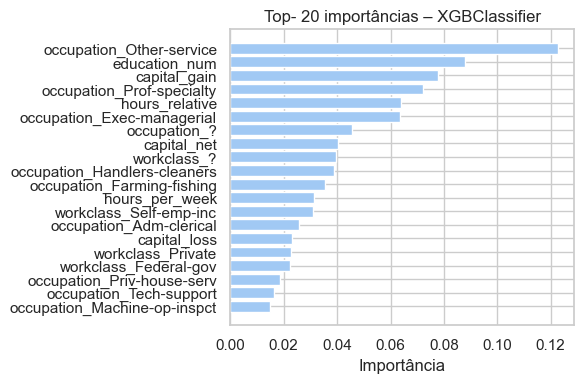

In [88]:
# 1. Recuperar nomes das features após o ColumnTransformer
preproc  = final_pipeline.named_steps['preprocessor']
model    = final_pipeline.named_steps['model']
top_k=20



# num_features
num_features = preproc.transformers_[0][2]

# cat_features (expandidos pelo OneHot)
cat_encoder      = preproc.named_transformers_['cat'].named_steps['encoder']
cat_features_raw = preproc.transformers_[1][2]
cat_feature_names = cat_encoder.get_feature_names_out(cat_features_raw)

feature_names = np.concatenate([num_features, cat_feature_names])

# 2. Extrair importâncias
if hasattr(model, "feature_importances_"):
    # RandomForest, XGBClassifier, LGBMClassifier
    importances = model.feature_importances_
    
elif isinstance(model, SVC) and model.kernel == "linear":
    # |coef_| para SVM linear
    importances = np.abs(model.coef_).flatten()
    
else:
    # Qualquer modelo sem atributo nativo → permutação
    perm = permutation_importance(
        final_pipeline, X_val, y_val,
        n_repeats=10, scoring="roc_auc",
        n_jobs=-1, random_state=42
    )
    importances = perm.importances_mean

# 3. Organizar e selecionar as k variáveis mais relevantes
imp_df = (pd.DataFrame({"feature": feature_names,
                        "importance": importances})
            .sort_values("importance", ascending=False)
            .head(top_k))

#Plotando o gráfico
plt.figure(figsize=(6, 4))
plt.barh(imp_df["feature"][::-1],          
         imp_df["importance"][::-1])
plt.xlabel("Importância")
plt.title(f"Top- {top_k} importâncias – {type(model).__name__}")
plt.tight_layout()
plt.show()
    

Sendo assim, as features mais significativas foram Ocupação, Grau de Escolaridade e Ganho de capital.

# Avaliação Final do modelo

In [90]:
with open("best_model/pipeline_rf.pkl", "rb") as f:
    pipeline_carregado = pickle.load(f)


# Gerar previsões finais
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1] if hasattr(final_model, "predict_proba") else None


Após carregar o modelo e inferir os dados é possível verificar os resultados analisando a predição pela base de teste:

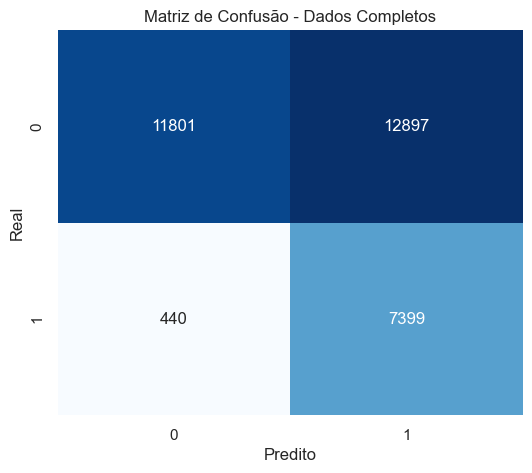

In [92]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão - Dados Completos")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


Fórmulas utilizadas para construir as métricas globais de classificação:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$  

$$
\text{Precision} = \frac{TP}{TP + FP}
$$  

$$
\text{Recall} = \frac{TP}{TP + FN}
$$  

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
                {\text{Precision} + \text{Recall}}
$$


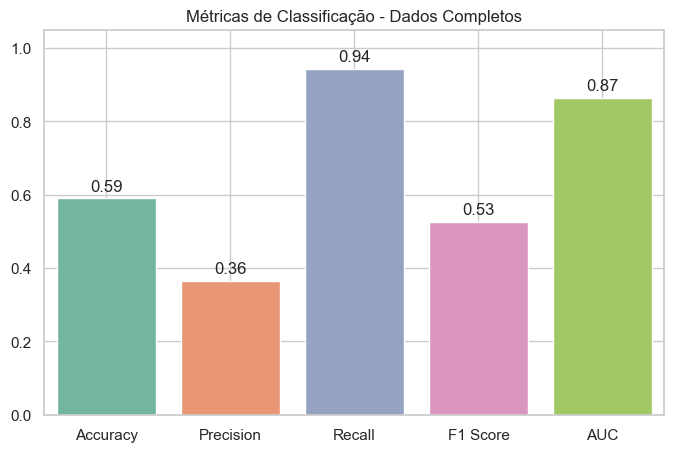

In [94]:
# Barplot com métricas
metrics_dict = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(metrics_dict.keys()), y=list(metrics_dict.values()), palette="Set2")
plt.ylim(0, 1.05)
plt.title("Métricas de Classificação - Dados Completos")
for i, v in enumerate(metrics_dict.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.grid(True)
plt.show()

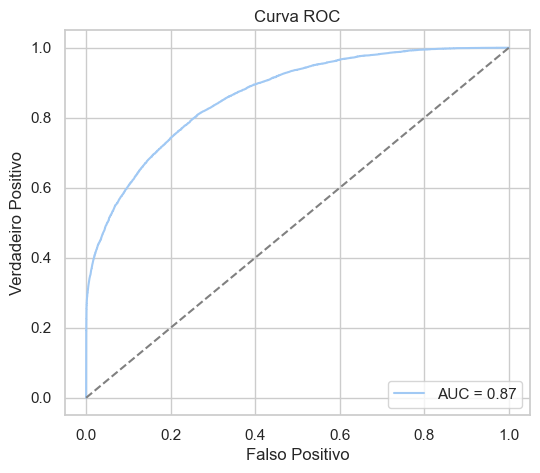

In [95]:
# Curva ROC
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("Falso Positivo")
    plt.ylabel("Verdadeiro Positivo")
    plt.title("Curva ROC")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()


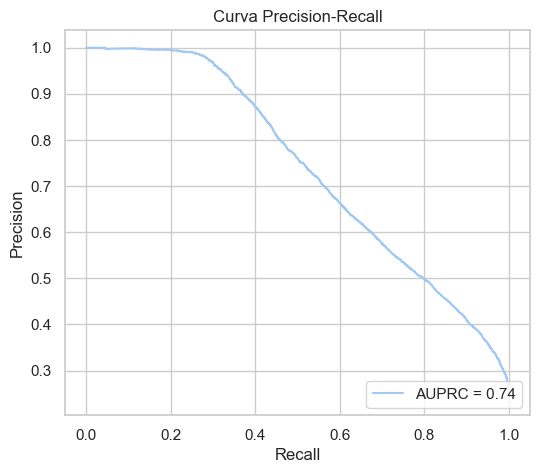

In [96]:
# Curva Precision-Recall
if y_proba is not None:
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    auprc_trap = auc(recall, precision)   
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {auprc_trap:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Curva Precision-Recall")
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

Avaliando o modelo na base de teste, é possível observar que o XGBoost manteve o desempenho no teste em termos de AUC. A curva ROC, que indica o poder global de separação entre as classes em todos os limiares, manteve-se bem acima da diagonal, resultando em AUC de aproximadamente 0.87, mostrando que o modelo possui um bom ajuste quando comparado a taxa de verdadeiro positivo com falso positivo que representa a classe de acumulo de renda maior que 50.000 dolares.

Na matriz de confusão, prevalece o erro do tipo I, falso positivo. E quando olhamos para as métricas globais de revocação, precisão, acurácia e média harmônica entre precisão e revocação, temos que apenas o Recall foi alto, evidenciando um baixo desempenho do modelo, que pode ser justificado pela remoção de algumas features com alto poder explicativo. 

E por fim, como as classes são desbalanceadas utilizamos a curva Precision-Recall, para analisar a confiabilidade das predições para as classes positivas, que nesse cenário são os acúmulos de renda anual maior que 50.000 dolares, a medida que é priorizado a “não perder os casos positivos”. E assim, observamos que há um caimento da reta precocemente, mostrando a baixa confiabilidade de assertividade do modelo.

Por fim, concluímos que o modelo não tevem bom desempenho final lembrando que algumas variáveis explicativas retiradas do treinamento, priorizando o uso da inteligência artificial de forma responsável em um cenário real, sendo que incluindo elas poderiam elevar as métricas de desempenho do modelo.


<b>Notebook disponível em:</b> https://drive.google.com/file/d/1PeGgB9Q6DCdowkIguLTC_jTntKEeSGsg/view?usp=sharing

<b>Link do vídeo no youtube: </b>https://youtu.be/x4dY5ONRIdQ

<b>Referências utilizadas:</b>

- PULLAKANDAM, Krishna. Hyper-parameter pruning with Optuna: efficient machine learning optimization. Medium, 23 ago. 2024. Disponível em: <https://krishnapullak.medium.com/hyper-parameter-pruning-with-optuna-efficient-machine-learning-optimization-7c2c9abd217d>. Acesso em: 23 jun. 2025.
- OPTUNA. Optuna (publicação em Medium). Medium, 2023-2025 (em atualização). Disponível em: <https://medium.com/optuna>. Acesso em: 23 jun. 2025.
- AKIBA, Takuya; SANO, Shotaro; YANASE, Toshihiko; OHTA, Takeru; KOYAMA, Masanori. Optuna: a next-generation hyperparameter optimization framework. In: KDD ’19 – Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, p. 2623-2631, 2019. DOI: 10.1145/3292500.3330701.
- SHUKLA, Rahul. Adult income prediction: Adult Income dataset from UCI — classification with various models. Medium, 23 set. 2020. Disponível em: <https://medium.com/@rahulshuklawork/adult-income-prediction-933be5eb953e>. Acesso em: 23 jun. 2025.
- JOHNSON, Ada. Adult Census Income dataset: using multiple machine learning models. Medium – Analytics Vidhya, 27 set. 2020. Disponível em: <https://medium.com/analytics-vidhya/adult-census-income-dataset-using-multiple-machine-learning-models-f289c960005d>. Acesso em: 23 jun. 2025.
